### Load all recent Synoptic Weather API data 

Notebook contents 
* Plot timeseries by water year for each site 

created by Cassie Lumbrazo\
last updated: March 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()

# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

In [2]:
pwd

'/home/cassie/python/repos/snowdepth_teleconnections'

In [4]:
# save the df_snow_smooth dataframe to a csv file
# df_snow_smooth.to_csv('/home/cassie/python/repos/snowdepth_teleconnections/snow_depth_comparison_2015_2026.csv')

# load the saved csv file back into a dataframe
df_snow_smooth = pd.read_csv('/home/cassie/python/repos/snowdepth_teleconnections/snow_depth_comparison_2015_2026.csv', index_col=0, parse_dates=True)
df_snow_smooth.head()

,snotel,powderpatch,tram,snotel_smooth,powderpatch_smooth,tram_smooth
datetime,,,,,,
2015-10-01 00:00:00,0.0,NaN,4.33,0.0,NaN,4.250287
2015-10-01 01:00:00,0.0,NaN,4.33,0.0,NaN,4.243586
2015-10-01 02:00:00,0.0,NaN,4.33,0.0,NaN,4.236891
2015-10-01 03:00:00,0.0,NaN,4.33,0.0,NaN,4.230201
2015-10-01 04:00:00,0.0,NaN,4.72,0.0,NaN,4.223516


In [24]:
df_snow_clean = df_snow_smooth.copy()

# Step 1: Compute water year (1 Sep - 31 Aug)
df_snow_clean['datetime'] = pd.to_datetime(df_snow_clean.index)  # Ensure datetime
df_snow_clean['water_year'] = df_snow_clean['datetime'].apply(
    lambda d: d.year + 1 if d.month >= 9 else d.year  # Sep (9) or later = next year
)

df_snow_clean

,snotel,powderpatch,tram,snotel_smooth,powderpatch_smooth,tram_smooth,datetime,water_year
datetime,,,,,,,,
2015-10-01 00:00:00,0.0,NaN,4.33,0.0,NaN,4.250287,2015-10-01 00:00:00,2016
2015-10-01 01:00:00,0.0,NaN,4.33,0.0,NaN,4.243586,2015-10-01 01:00:00,2016
2015-10-01 02:00:00,0.0,NaN,4.33,0.0,NaN,4.236891,2015-10-01 02:00:00,2016
2015-10-01 03:00:00,0.0,NaN,4.33,0.0,NaN,4.230201,2015-10-01 03:00:00,2016
2015-10-01 04:00:00,0.0,NaN,4.72,0.0,NaN,4.223516,2015-10-01 04:00:00,2016
...,...,...,...,...,...,...,...,...
2026-03-20 05:00:00,NaN,98.54,NaN,NaN,91.451217,NaN,2026-03-20 05:00:00,2026
2026-03-20 06:00:00,NaN,98.82,NaN,NaN,91.465859,NaN,2026-03-20 06:00:00,2026
2026-03-20 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-20 07:00:00,2026


# Plot by Water Year

In [19]:
df = df_snow_clean.copy(deep=True)

In [8]:
# # Step 2: Define water year max thresholds
# wy_max_depth = {
#     2012: 600, # mesonet only, not great 
#     2013: 600, # mesonet only, not great 
#     2014: 600, # mesonet only, not great 
#     2015: 600, # mesonet only, not great 
#     2016: 250,
#     2017: 350,
#     2018: 350,
#     2019: 250,
#     2020: 500, # the data for this year is pretty tough, might need to remove a lot.. come back to this value 
#     2021: 500,
#     2022: 500,
#     2023: 400,
#     2024: 400,
#     2025: 400,
# }

# # Step 3: Clean snow depth columns based on water year-specific max
# for col in ['mesonet_SDIRZZ', 'mesonet_SDIRZZZ', 'mesowest_snow_depth_set_1']:
#     if col in df_snow_clean.columns:
#         df_snow_clean[col] = df_snow_clean.apply(
#             lambda row: row[col] if (0 <= row[col] <= wy_max_depth.get(row['water_year'], 450)) else None,
#             axis=1
#         )

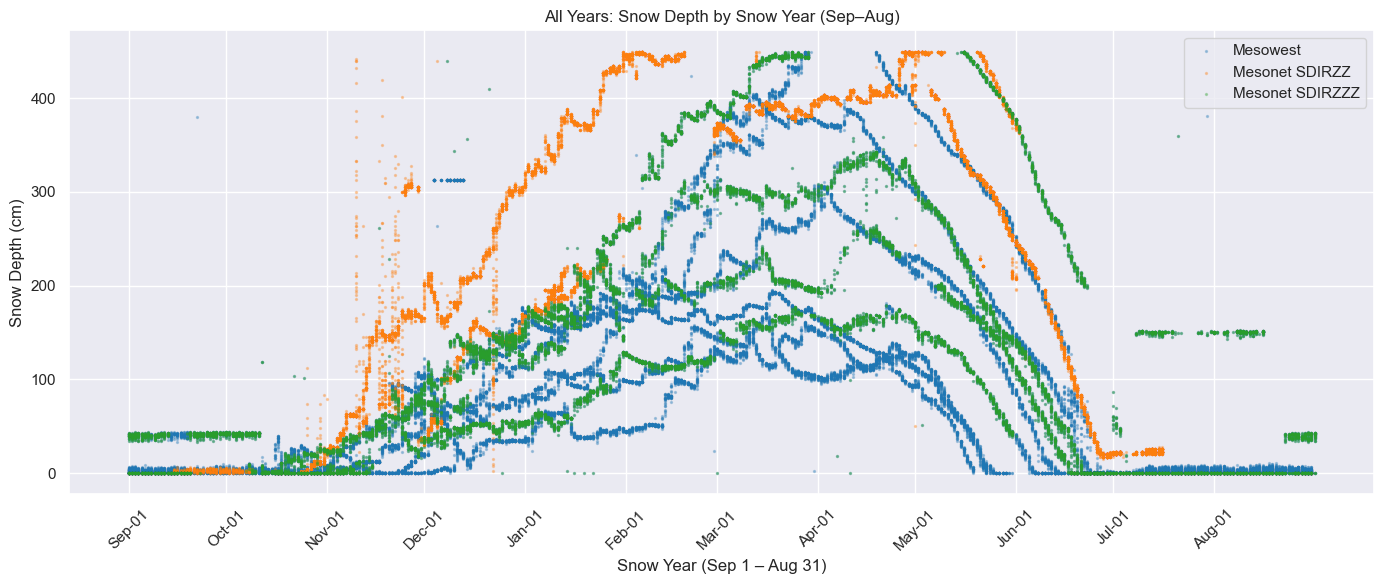

In [ ]:
# Make sure your index is a DatetimeIndex
# df = df_snow_clean.copy()
if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index)

# Create a custom "snow year" day label (starting Sep 1)
def get_snow_year_day(dt):
    snow_year_start = pd.Timestamp(year=dt.year if dt.month >= 9 else dt.year - 1, month=9, day=1)
    return (dt - snow_year_start).days

# Also create a label for plotting (e.g., "Sep-01", "Jan-15", etc.)
df['snow_year_day'] = df.index.map(get_snow_year_day)
df['month_day'] = df.index.strftime('%b-%d')

# Plot
plt.figure(figsize=(14, 6))

# for col, label, color in [
#     ('mesowest_sd1', 'Mesowest', 'tab:blue'),
#     ('mesonet_sd1', 'Mesonet SDIRZZ', 'tab:orange'),
#     ('mesonet_sd2', 'Mesonet SDIRZZZ', 'tab:green')
]:
    if col in df.columns:
        series = df[[col, 'snow_year_day']].dropna()
        plt.scatter(
            series['snow_year_day'],
            series[col],
            s=2, alpha=0.3,
            label=label, color=color
        )

# Set custom x-ticks (every month)
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels, rotation=45)

plt.xlabel('Snow Year (Sep 1 – Aug 31)')
plt.ylabel('Snow Depth (cm)')
plt.title('All Years: Snow Depth by Snow Year (Sep–Aug)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Okay, that looks great... the issue with this is that we are not providing a legend with the water year assosiated with year plot... let's fix that. 

A water year starts on October 1 and ends on September 30 of the next year. So:

For any date in October–December, water_year = year + 1

For any date in January–September, water_year = year

In [35]:
df = df_snow_clean.copy()

# Remove timezone if needed
df.index = df.index.tz_convert(None)

# Assign water year
df['water_year'] = df.index.map(lambda d: d.year + 1 if d.month >= 10 else d.year)

In [36]:
def get_snow_year_day(dt):
    snow_year_start = pd.Timestamp(year=dt.year if dt.month >= 9 else dt.year - 1, month=9, day=1)
    return (dt - snow_year_start).days

df['snow_year_day'] = df.index.map(get_snow_year_day)

In [37]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

/tmp/ipykernel_1195901/3687862713.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(water_years))


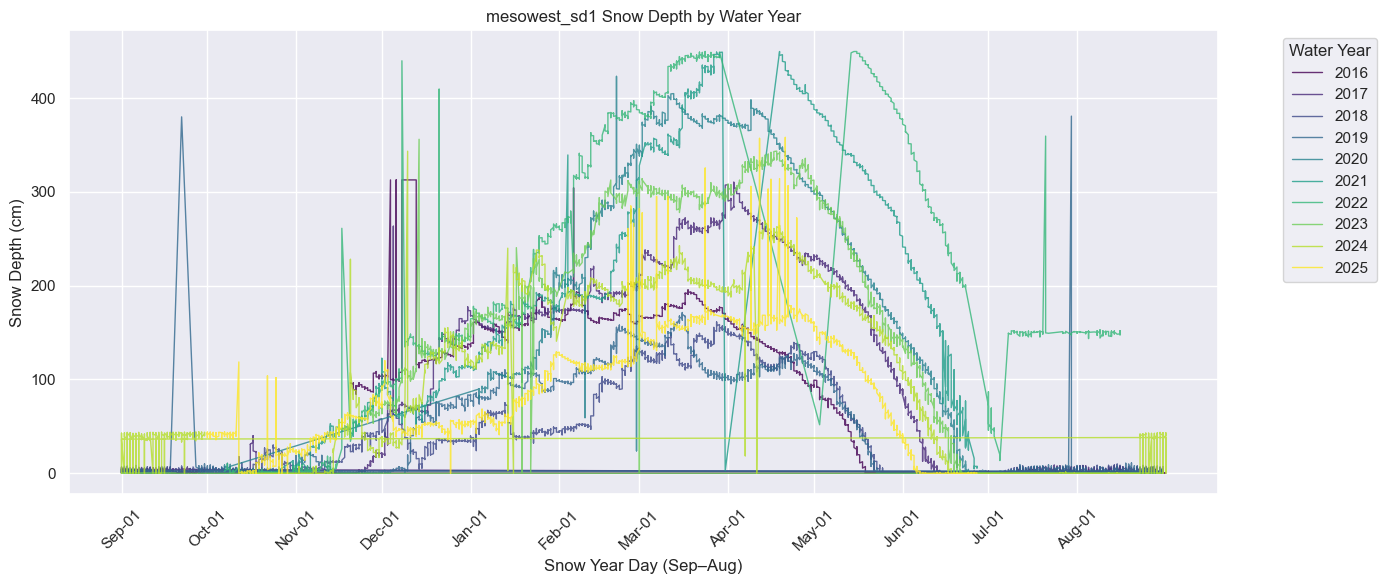

In [38]:
# Choose snow depth column to plot
depth_col = 'mesowest_sd1'  # or 'mesonet_sd1', etc.

# Drop NaN values for that column
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Set up unique years and colors
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = cm.get_cmap('viridis', len(water_years))
sm = cm.ScalarMappable(norm=norm, cmap=cmap)  # for legend

# Create plot
plt.figure(figsize=(14, 6))

for i, year in enumerate(water_years):
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.plot(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.8,
        linewidth=1
    )

# Customize x-axis ticks (same as before)
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels, rotation=45)

plt.xlabel('Snow Year Day (Sep–Aug)')
plt.ylabel('Snow Depth (cm)')
plt.title(f'{depth_col} Snow Depth by Water Year')
plt.grid(True)

# Legend
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

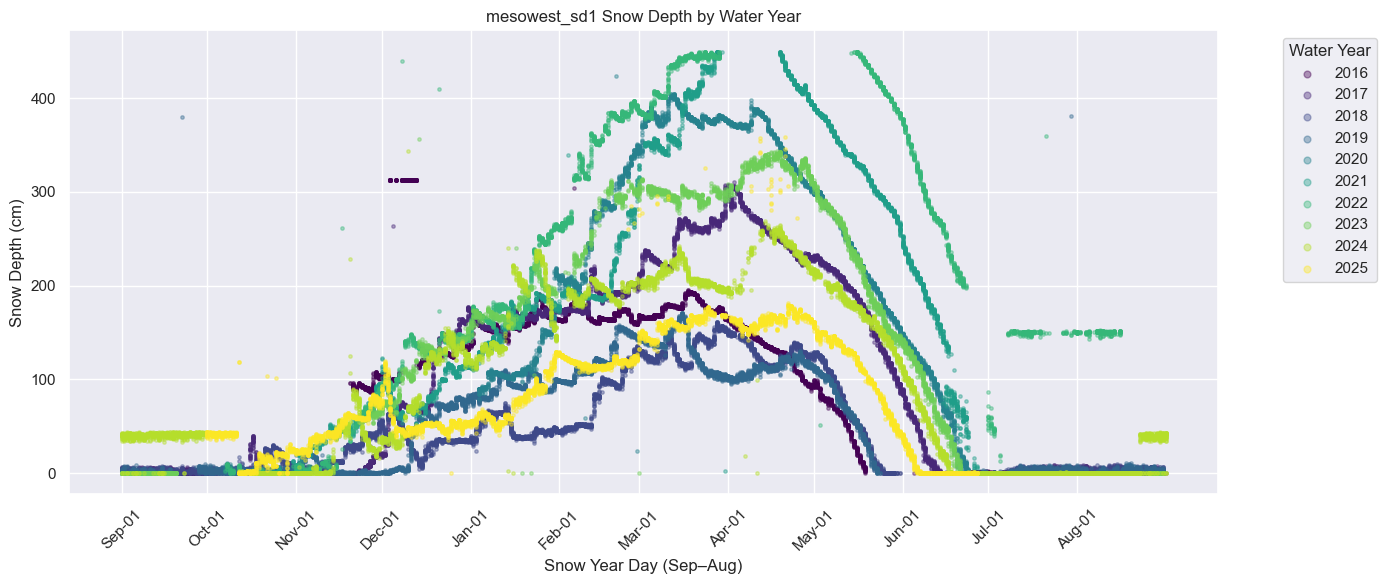

In [39]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
# import matplotlib.colormaps as colormaps  # New-style access
import matplotlib

# Choose depth column
depth_col = 'mesowest_sd1'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.4,
        s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels, rotation=45)
plt.xlabel('Snow Year Day (Sep–Aug)')
plt.ylabel('Snow Depth (cm)')
plt.title(f'{depth_col} Snow Depth by Water Year')
plt.grid(True)
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

add a black trend line... 

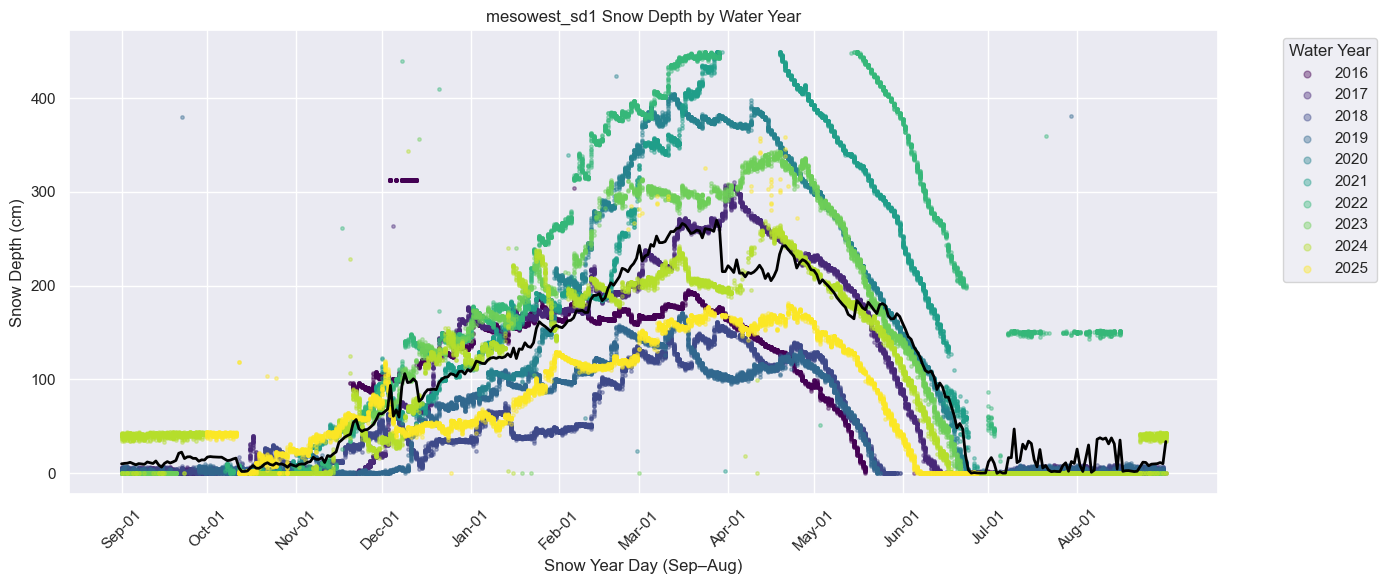

In [40]:
# Choose depth column
depth_col = 'mesowest_sd1'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.4,
        s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels, rotation=45)
plt.xlabel('Snow Year Day (Sep–Aug)')
plt.ylabel('Snow Depth (cm)')
plt.title(f'{depth_col} Snow Depth by Water Year')
plt.grid(True)
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
plt.tight_layout()

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='Mean Across Years'
)

plt.show()

Add a label to the line, and a confidence interval 

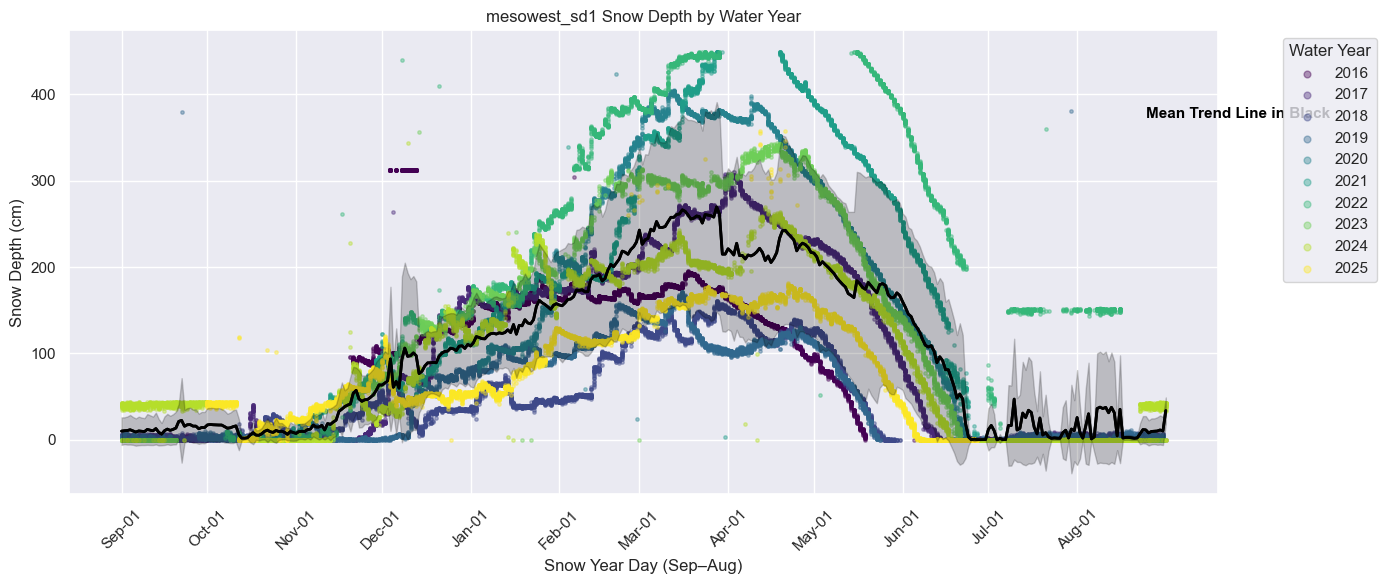

In [41]:
# Choose depth column
depth_col = 'mesowest_sd1'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.4,
        s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels, rotation=45)
plt.xlabel('Snow Year Day (Sep–Aug)')
plt.ylabel('Snow Depth (cm)')
plt.title(f'{depth_col} Snow Depth by Water Year')
plt.grid(True)
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
plt.tight_layout()

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='Mean Across Years'
)

# --- Calculate mean and std by snow_year_day ---
grouped = df_plot.groupby('snow_year_day')[depth_col]
mean_by_day = grouped.mean()
std_by_day = grouped.std()

# Plot shaded confidence interval (mean ± 1 std)
plt.fill_between(
    mean_by_day.index,
    mean_by_day - std_by_day,
    mean_by_day + std_by_day,
    color='black',
    alpha=0.2,
    label='±1 Std Dev'
)

# Plot average trend line
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='Mean Across Years'
)

# Label the line near the seasonal peak (customize as needed)
peak_day = mean_by_day.idxmax()
peak_value = mean_by_day.max()

plt.text(
    x=peak_day + 150,  # shift right or left
    y=peak_value + 100, # shift up or down
    s='Mean Trend Line in Black',
    fontsize=11,
    color='black',
    fontweight='bold',
    va='bottom',
    ha='left'
)

plt.show()

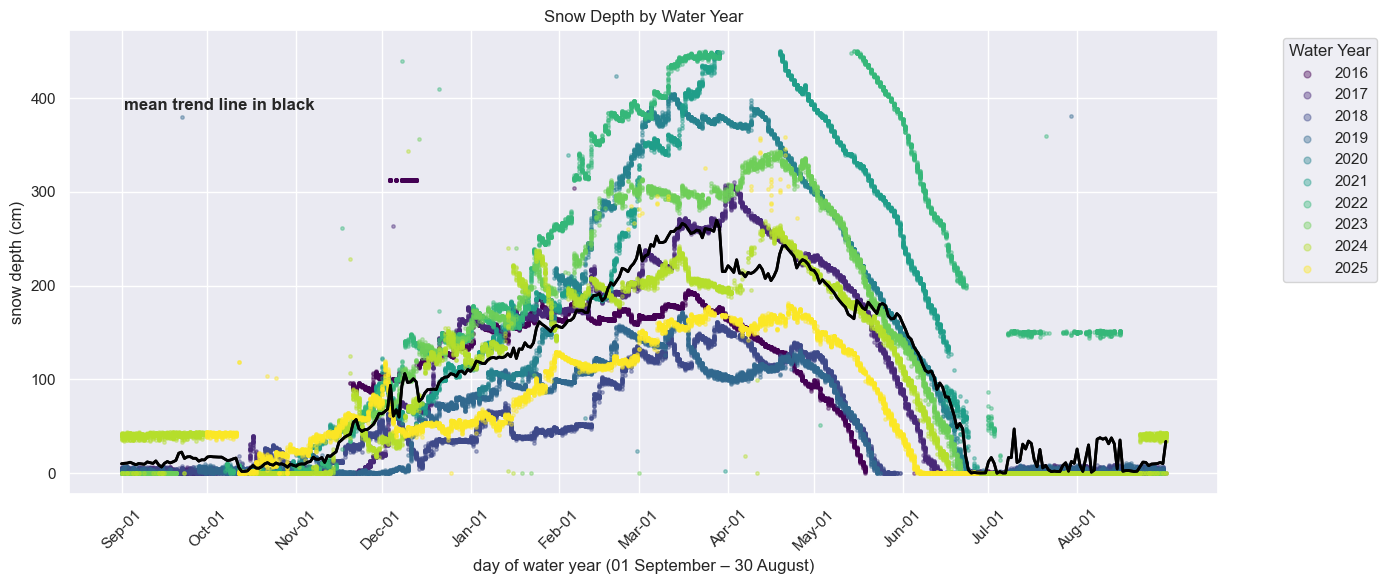

In [42]:
# Choose depth column
depth_col = 'mesowest_sd1'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.4,
        s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels, rotation=45)
plt.xlabel('day of water year (01 September – 30 August)')
plt.ylabel('snow depth (cm)')
plt.title('Snow Depth by Water Year')
plt.grid(True)
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
plt.tight_layout()

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='Mean Across Years'
)

# # --- Calculate mean and std by snow_year_day ---
# grouped = df_plot.groupby('snow_year_day')[depth_col]
# mean_by_day = grouped.mean()
# std_by_day = grouped.std()

# # Plot shaded confidence interval (mean ± 1 std)
# plt.fill_between(
#     mean_by_day.index,
#     mean_by_day - std_by_day,
#     mean_by_day + std_by_day,
#     color='black',
#     alpha=0.2,
#     label='±1 Std Dev'
# )

# Plot average trend line
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='Mean Across Years'
)

# # Label the line near the seasonal peak (customize as needed)
# peak_day = mean_by_day.idxmax()
# peak_value = mean_by_day.max()

# plt.text(
#     x=peak_day + 150,  # shift right or left
#     y=peak_value + 100, # shift up or down
#     s='Mean Trend Line in Black',
#     fontsize=11,
#     color='black',
#     fontweight='bold',
#     va='bottom',
#     ha='left'
# )

# add simple text in the upper right of the plot 
plt.text(x=1, y=400, s='mean trend line in black', fontweight='bold', va='top', ha='left')

plt.show()

Make this figure with `df_snow_clean_smoothed`, need to make the water year thing first,

In [43]:
import statsmodels.api as sm
# Set smoothing parameter
frac = 0.01  # Adjust this for more/less smoothing

# Reset index to access 'datetime' as a column
df_snow_clean_smoothed = df_snow_clean.reset_index()

# Apply LOWESS smoothing to all numeric columns
for col in ["mesonet_sd1", "mesonet_sd2", "mesowest_sd1"]:
    df_snow_clean_smoothed[col] = sm.nonparametric.lowess(
        df_snow_clean_smoothed[col], df_snow_clean_smoothed["datetime"], frac=frac, return_sorted=False
    )

# Restore datetime as index
df_snow_clean_smoothed.set_index("datetime", inplace=True)

In [44]:
df = df_snow_clean_smoothed.copy()

# Remove timezone if needed
df.index = df.index.tz_convert(None)

# Assign water year
df['water_year'] = df.index.map(lambda d: d.year + 1 if d.month >= 10 else d.year)

def get_snow_year_day(dt):
    snow_year_start = pd.Timestamp(year=dt.year if dt.month >= 9 else dt.year - 1, month=9, day=1)
    return (dt - snow_year_start).days

df['snow_year_day'] = df.index.map(get_snow_year_day)

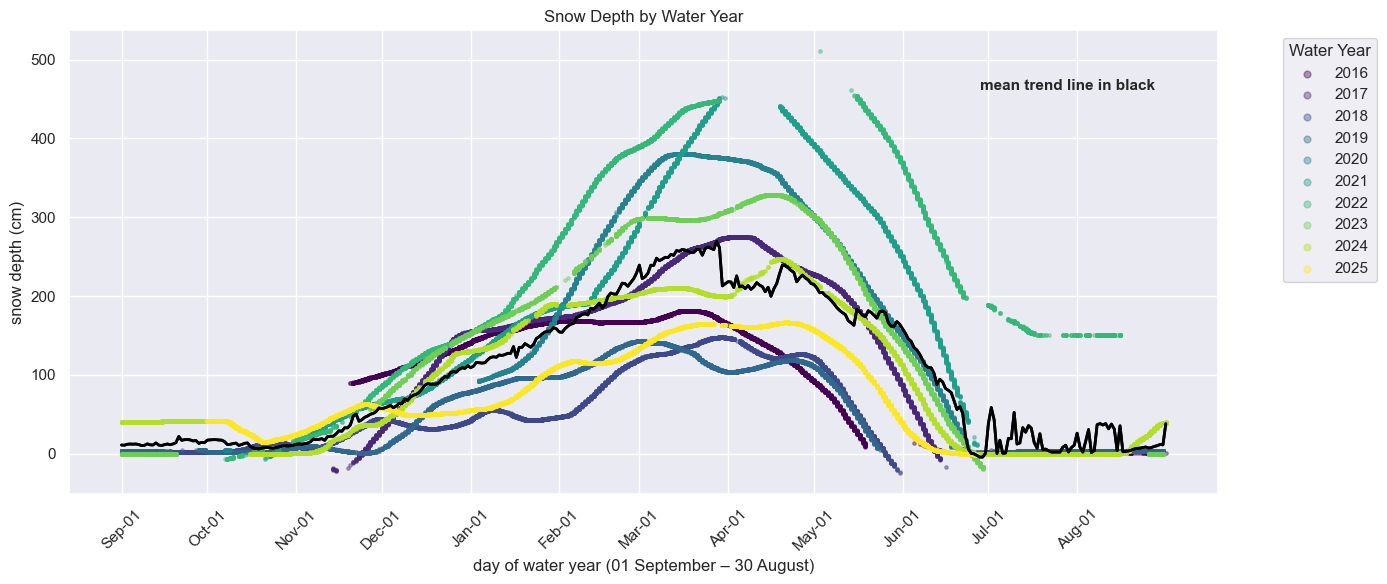

In [45]:
# Choose depth column
depth_col = 'mesowest_sd1'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.4,
        s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels, rotation=45)
plt.xlabel('day of water year (01 September – 30 August)')
plt.ylabel('snow depth (cm)')
plt.title('Snow Depth by Water Year')
plt.grid(True)
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
plt.tight_layout()

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='Mean Across Years'
)

# Plot average trend line
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='Mean Across Years'
)

# add simple text in the upper right of the plot 
plt.text(x=300, y=475, s='mean trend line in black', fontsize=11, fontweight='bold', va='top', ha='left')

plt.show()

Okay, that looks weird... 

need to come back to the smoothing, but here is an example of how Jason has used it, 

In [46]:
df

,index,mesonet_sd1,mesonet_sd2,mesowest_sd1,water_year,snow_year_day
datetime,,,,,,
2010-12-15 22:00:00,2010-12-15 22:00:00+00:00,34.482771,NaN,NaN,2011,105
2011-01-09 04:15:00,2011-01-09 04:15:00+00:00,31.903802,NaN,NaN,2011,130
2011-05-21 03:45:00,2011-05-21 03:45:00+00:00,17.849873,NaN,NaN,2011,262
2011-05-21 04:15:00,2011-05-21 04:15:00+00:00,17.847648,NaN,NaN,2011,262
2011-05-21 04:45:00,2011-05-21 04:45:00+00:00,17.845423,NaN,NaN,2011,262
...,...,...,...,...,...,...
2025-06-27 08:00:00,2025-06-27 08:00:00+00:00,NaN,NaN,-1.330123,2025,299
2025-06-27 09:00:00,2025-06-27 09:00:00+00:00,NaN,NaN,-1.337867,2025,299
2025-06-27 10:00:00,2025-06-27 10:00:00+00:00,NaN,NaN,-1.345585,2025,299


In [47]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# df = df_snow_clean.copy()
timespan = df.iloc[-1].doy - df.iloc[0].doy
 
df_smooth = lowess(df.northing, df.doy, frac=1/timespan, it=1, delta=0.1, return_sorted=False)

AttributeError: 'Series' object has no attribute 'doy'

Done for now, come back to this to fix later.

### Previous attempt at smoothing... using the code above instead, but come back if I need this. 

In [ ]:
# from statsmodels.nonparametric.smoothers_lowess import lowess

In [ ]:
# def smooth_loess(series, frac=0.05):
#     """
#     Smooth a time series using LOESS (LOWESS).
#     Args:
#         series: pandas Series with datetime index.
#         frac: Smoothing span (fraction of data to use in each local fit).
#     Returns:
#         Smoothed pandas Series with same index.
#     """
#     if series.isna().all():
#         return series.copy()  # Avoid crashing on all-NaN input

#     # Drop NaNs for fitting
#     valid = series.dropna()
#     x = valid.index.astype(np.int64)  # convert datetime to int for LOWESS
#     y = valid.values

#     smoothed = lowess(endog=y, exog=x, frac=frac, return_sorted=False)

#     # Return a full Series with NaNs where data was missing
#     smooth_series = pd.Series(index=series.index, dtype='float64')
#     smooth_series[valid.index] = smoothed
#     return smooth_series

In [ ]:
# df_snow_loess = df_snow_clean.copy()

# for col in ['mesonet_SDIRZZ', 'mesonet_SDIRZZZ', 'mesowest_snow_depth_set_1']:
#     if col in df_snow_loess.columns:
#         df_snow_loess[col] = smooth_loess(df_snow_clean[col], frac=0.05)